# Segmentacion con Inteligencia Artificial


### Sustitucion por datasets reales

Para usar este notebook con datos reales, reemplaza la seccion 2 por:

| Dataset | Clases | Como descargarlo |
|---------|--------|------------------|
| **Oxford-IIIT Pet** | 3 (mascota/fondo/borde) | `torchvision.datasets.OxfordIIITPet(target_types='segmentation')` |
| **ISIC 2018** (lesion melanoma) | 2 | isic-challenge.s3.amazonaws.com |
| **DRIVE** (vasos retinianos) | 2 | grand-challenge.org/DRIVE |
| **MoNuSeg** (nucleos celulares) | 2 | monuseg.grand-challenge.org |
| **Cityscapes** (conduccion) | 19 | `torchvision.datasets.Cityscapes` |

---

## Contenidos

1. Fundamentos y formulacion matematica
2. Dataset
3. Arquitectura FCN
4. Arquitectura U-Net con skip connections
5. Funciones de perdida
6. Metricas de evaluacion
7. Data augmentation sincronizada
8. Entrenamiento y comparativa
9. Analisis de resultados

---

## 1. Fundamentos y formulacion matematica

La segmentacion semantica asigna una etiqueta de clase a cada pixel de la imagen:

$$f_\theta : \mathbb{R}^{H \times W \times C} \rightarrow \{0, \ldots, K-1\}^{H \times W}$$

La red produce logits de forma $(B, K, H, W)$. La prediccion final por pixel es:

$$\hat{y}_{ij} = \arg\max_k \; \text{softmax}(\text{logits})_{ijk}$$

A diferencia de la clasificacion de imagenes, la segmentacion debe preservar la resolucion espacial a lo largo de toda la red. Esto requiere arquitecturas encoder-decoder que compriman la representacion semanticamente y luego la expandan recuperando el detalle espacial.

---

## 2. dataset

In [2]:
import torchvision
import torchvision.transforms.functional as TF
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms.functional as TF

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import random
N_CLASSES    = 3
IMG_H, IMG_W = 128, 128
CLASS_NAMES  = ['Fondo', 'Mascota', 'Borde']
CLASS_COLORS = [
    (0,   0,   0),
    (255, 255, 255),
    (128, 128, 128),
]

def load_pair(img, mask):
    img  = TF.resize(img,  [IMG_H, IMG_W])
    mask = TF.resize(mask, [IMG_H, IMG_W], interpolation=TF.InterpolationMode.NEAREST)
    img_t  = TF.to_tensor(img)
    mask_t = torch.from_numpy(np.array(mask)).long() - 1
    mask_t = mask_t.clamp(0, N_CLASSES - 1)
    return img_t, mask_t


class OxfordPetSeg(Dataset):
    def __init__(self, split='trainval'):
        self.raw = torchvision.datasets.OxfordIIITPet(
            root='./data', split=split,
            target_types='segmentation', download=True,
        )

    def __len__(self):
        return len(self.raw)

    def __getitem__(self, idx):
        img, mask = self.raw[idx]
        img  = TF.resize(img,  [IMG_H, IMG_W])
        mask = TF.resize(mask, [IMG_H, IMG_W],
                         interpolation=TF.InterpolationMode.NEAREST)
        img_t  = TF.to_tensor(img)
        mask_t = torch.from_numpy(np.array(mask)).long() - 1
        mask_t = mask_t.clamp(0, N_CLASSES - 1)
        return img_t, mask_t


train_dataset = OxfordPetSeg('trainval')
test_dataset  = OxfordPetSeg('test')

n_val   = int(len(train_dataset) * 0.2)
n_train = len(train_dataset) - n_val
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE   = 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

imgs_b, masks_b = next(iter(train_loader))
print(f'Batch imagenes : {imgs_b.shape}')
print(f'Batch mascaras : {masks_b.shape}')
print(f'Clases unicas  : {masks_b.unique().tolist()}')

Batch imagenes : torch.Size([4, 3, 128, 128])
Batch mascaras : torch.Size([4, 128, 128])
Clases unicas  : [0, 1, 2]


---

## 3. Arquitectura FCN (Fully Convolutional Network)

Long et al. (2015) propusieron sustituir las capas densas de una CNN por convoluciones $1\times1$ y recuperar la resolucion con upsampling bilineal. **Limitacion:** el upsampling desde $H/16$ produce bordes difusos porque la informacion espacial fina se perdio en el pooling y no hay forma de recuperarla.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo : {device}')
print(f'PyTorch     : {torch.__version__}')
class CBR(nn.Module):
    """Conv → BatchNorm → ReLU. Bloque base de ambas arquitecturas."""
    def __init__(self, i, o, k=3, p=1):
        super().__init__()
        self.b = nn.Sequential(
            nn.Conv2d(i, o, k, padding=p, bias=False),
            nn.BatchNorm2d(o), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.b(x)


class SimpleFCN(nn.Module):
    """
    Fully Convolutional Network para segmentacion.

    Encoder: 4 niveles de doble conv + MaxPool (reduccion x16 total).
    Cabeza:  Conv 1x1 produce K logits por ubicacion espacial.
    Decoder: interpolacion bilineal restaura la resolucion original.
    """
    def __init__(self, n_classes=4, in_ch=3, f=32):
        super().__init__()
        self.enc = nn.Sequential(
            CBR(in_ch,f), CBR(f,f),     nn.MaxPool2d(2),
            CBR(f,f*2),   CBR(f*2,f*2), nn.MaxPool2d(2),
            CBR(f*2,f*4), CBR(f*4,f*4), nn.MaxPool2d(2),
            CBR(f*4,f*8), CBR(f*8,f*8), nn.MaxPool2d(2),
        )
        self.head = nn.Conv2d(f*8, n_classes, 1)

    def forward(self, x):
        h, w = x.shape[2], x.shape[3]
        x = self.head(self.enc(x))
        return F.interpolate(x, size=(h,w), mode='bilinear', align_corners=False)


# Verificar
dummy = torch.randn(2, 3, IMG_H, IMG_W).to(device)
_fcn  = SimpleFCN(N_CLASSES).to(device)
print(f'FCN    | {dummy.shape} -> {_fcn(dummy).shape} | params: {sum(p.numel() for p in _fcn.parameters()):,}')
del _fcn

Dispositivo : cuda
PyTorch     : 2.10.0+cu128
FCN    | torch.Size([2, 3, 128, 128]) -> torch.Size([2, 3, 128, 128]) | params: 1,173,987


---

## 4. Arquitectura U-Net con skip connections

U-Net (Ronneberger et al., 2015) resuelve la limitacion de la FCN con **skip connections**: concatena directamente cada nivel del encoder con el nivel simetrico del decoder, aportando el detalle espacial fino que el bottleneck no puede recuperar por si solo.

In [4]:
class DoubleConv(nn.Module):
    """Bloque doble Conv→BN→ReLU→Conv→BN→ReLU tipico de U-Net."""
    def __init__(self, i, o):
        super().__init__()
        self.b = nn.Sequential(
            nn.Conv2d(i,o,3,padding=1,bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
            nn.Conv2d(o,o,3,padding=1,bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.b(x)


class UNet(nn.Module):
    """
    U-Net para segmentacion semantica.

    En cada nivel del decoder:
      1. ConvTranspose2d duplica la resolucion espacial.
      2. Se concatena con el skip del encoder del mismo nivel.
      3. DoubleConv fusiona la informacion semantica (up) y espacial (skip).

    La concatenacion duplica los canales de entrada del DoubleConv del decoder:
    f*k (de up) + f*k (skip) = f*2k canales de entrada.
    """
    def __init__(self, in_ch=3, n_classes=4, f=32):
        super().__init__()
        # Encoder
        self.e1 = DoubleConv(in_ch, f)
        self.e2 = DoubleConv(f,    f*2)
        self.e3 = DoubleConv(f*2,  f*4)
        self.e4 = DoubleConv(f*4,  f*8)
        self.p  = nn.MaxPool2d(2)
        # Bottleneck
        self.bn = DoubleConv(f*8, f*16)
        # Decoder
        self.u4, self.d4 = nn.ConvTranspose2d(f*16,f*8,  2,stride=2), DoubleConv(f*16, f*8)
        self.u3, self.d3 = nn.ConvTranspose2d(f*8, f*4,  2,stride=2), DoubleConv(f*8,  f*4)
        self.u2, self.d2 = nn.ConvTranspose2d(f*4, f*2,  2,stride=2), DoubleConv(f*4,  f*2)
        self.u1, self.d1 = nn.ConvTranspose2d(f*2, f,    2,stride=2), DoubleConv(f*2,  f)
        self.out = nn.Conv2d(f, n_classes, 1)

    def forward(self, x):
        s1 = self.e1(x)
        s2 = self.e2(self.p(s1))
        s3 = self.e3(self.p(s2))
        s4 = self.e4(self.p(s3))
        b  = self.bn(self.p(s4))
        x  = self.d4(torch.cat([self.u4(b), s4], dim=1))
        x  = self.d3(torch.cat([self.u3(x), s3], dim=1))
        x  = self.d2(torch.cat([self.u2(x), s2], dim=1))
        x  = self.d1(torch.cat([self.u1(x), s1], dim=1))
        return self.out(x)


_unet = UNet(3, N_CLASSES, f=32).to(device)
print(f'U-Net  | {dummy.shape} -> {_unet(dummy).shape} | params: {sum(p.numel() for p in _unet.parameters()):,}')
del _unet

U-Net  | torch.Size([2, 3, 128, 128]) -> torch.Size([2, 3, 128, 128]) | params: 7,763,107


In [6]:
# Calcular pesos de clase desde el train_loader
class_counts = torch.zeros(N_CLASSES)
for _, m in train_loader:
    for c in range(N_CLASSES):
        class_counts[c] += (m == c).sum()

class_freqs   = class_counts / class_counts.sum()
class_weights = (1.0 / (class_freqs + 1e-6))
class_weights = (class_weights / class_weights.sum() * N_CLASSES).to(device)

print('Pesos de clase:')
for c in range(N_CLASSES):
    print(f'  {CLASS_NAMES[c]:<12}: {class_weights[c].item():.3f}')

Pesos de clase:
  Fondo       : 0.722
  Mascota     : 0.370
  Borde       : 1.908


---

## 5. Funciones de perdida para segmentacion

In [7]:
class SegLoss:
    """Funciones de perdida para segmentacion. Reciben logits (B,K,H,W) y targets (B,H,W)."""

    @staticmethod
    def ce(logits, targets, w=None):
        """Cross-Entropy pixelwise. Con w corrige desbalance de clases."""
        return F.cross_entropy(logits, targets, weight=w)

    @staticmethod
    def dice(logits, targets, n_classes, smooth=1.0):
        """
        Dice Loss = 1 - mean_c[ 2|P_c ∩ G_c| / (|P_c| + |G_c|) ]

        Trata todas las clases por igual sin importar su frecuencia.
        Ideal para clases minoritarias pequeñas (nucleos, lesiones).
        """
        p  = F.softmax(logits, dim=1)
        oh = F.one_hot(targets, n_classes).permute(0,3,1,2).float()
        ds = []
        for c in range(n_classes):
            inter = (p[:,c]*oh[:,c]).sum(dim=(1,2))
            union = p[:,c].sum(dim=(1,2)) + oh[:,c].sum(dim=(1,2))
            ds.append(((2*inter+smooth)/(union+smooth)).mean())
        return 1 - torch.stack(ds).mean()

    @staticmethod
    def focal(logits, targets, gamma=2.0, w=None):
        """
        Focal Loss: multiplica la CE por (1-p)^gamma.
        Reduce el peso de los pixeles faciles y enfoca el entrenamiento
        en los dificiles (bordes, clases raras con alta varianza).
        """
        ce  = F.cross_entropy(logits, targets, weight=w, reduction='none')
        pt  = F.softmax(logits,dim=1).gather(1,targets.unsqueeze(1)).squeeze(1)
        return ((1-pt)**gamma * ce).mean()

    @staticmethod
    def combined(logits, targets, n_classes, w=None, lam=0.5):
        """CE + lambda*Dice: estabilidad de gradiente + optimizacion de superposicion."""
        return SegLoss.ce(logits,targets,w) + lam*SegLoss.dice(logits,targets,n_classes)


# Demostrar perdidas
_m = UNet(3, N_CLASSES, f=16).to(device)
with torch.no_grad():
    lg = _m(imgs_b.to(device))
    gt = masks_b.to(device)
    print('Perdidas (modelo sin entrenar):')
    print(f'  CE              : {SegLoss.ce(lg,gt):.4f}')
    print(f'  Weighted CE     : {SegLoss.ce(lg,gt,class_weights):.4f}')
    print(f'  Dice Loss       : {SegLoss.dice(lg,gt,N_CLASSES):.4f}')
    print(f'  Focal (g=2)     : {SegLoss.focal(lg,gt):.4f}')
    print(f'  Combined        : {SegLoss.combined(lg,gt,N_CLASSES,class_weights):.4f}')
del _m, lg, gt

Perdidas (modelo sin entrenar):
  CE              : 1.1249
  Weighted CE     : 1.1185
  Dice Loss       : 0.6980
  Focal (g=2)     : 0.5418
  Combined        : 1.4675


---

## 6. Metricas de evaluacion

In [8]:
class SegMetrics:
    """Metricas estandar para segmentacion semantica."""

    @staticmethod
    def pixel_acc(preds, targets):
        """Fraccion de pixeles correctos. Sensible al desbalance de clases."""
        return (preds==targets).float().mean().item()

    @staticmethod
    def iou_per_class(preds, targets, n_classes):
        """IoU = TP / (TP+FP+FN). NaN para clases ausentes."""
        ious = []
        for c in range(n_classes):
            inter = ((preds==c)&(targets==c)).sum().item()
            union = ((preds==c)|(targets==c)).sum().item()
            ious.append(inter/union if union>0 else float('nan'))
        return ious

    @staticmethod
    def miou(preds, targets, n_classes):
        """mIoU: promedio de IoU sobre clases presentes. Metrica estandar."""
        v = [x for x in SegMetrics.iou_per_class(preds,targets,n_classes) if not np.isnan(x)]
        return float(np.mean(v)) if v else 0.0

    @staticmethod
    def dice_per_class(preds, targets, n_classes, eps=1e-6):
        """Dice/F1 = 2TP/(2TP+FP+FN). Estandar en imagenes medicas."""
        dices = []
        for c in range(n_classes):
            p = (preds==c).float(); g = (targets==c).float()
            inter = (p*g).sum().item(); denom = p.sum().item()+g.sum().item()
            dices.append((2*inter+eps)/(denom+eps) if denom>0 else float('nan'))
        return dices

    @staticmethod
    def mean_dice(preds, targets, n_classes):
        v = [x for x in SegMetrics.dice_per_class(preds,targets,n_classes) if not np.isnan(x)]
        return float(np.mean(v)) if v else 0.0


@torch.no_grad()
def evaluate(model, loader, n_classes, device):
    """Evalua el modelo sobre un DataLoader completo y retorna metricas globales."""
    model.eval()
    ps, ts = [], []
    for imgs, masks in loader:
        preds = model(imgs.to(device)).argmax(1).cpu()
        ps.append(preds); ts.append(masks)
    ps, ts = torch.cat(ps), torch.cat(ts)
    return {
        'pixel_acc'    : SegMetrics.pixel_acc(ps, ts),
        'mIoU'         : SegMetrics.miou(ps, ts, n_classes),
        'mean_dice'    : SegMetrics.mean_dice(ps, ts, n_classes),
        'iou_per_class': SegMetrics.iou_per_class(ps, ts, n_classes),
        'dice_per_class': SegMetrics.dice_per_class(ps, ts, n_classes),
        'preds': ps, 'targets': ts,
    }

---

## 7. Data augmentation sincronizada imagen + mascara

Toda transformacion geometrica debe aplicarse **identicamente** a imagen y mascara. La mascara usa interpolacion `NEAREST` para no mezclar etiquetas de clase. Las transformaciones de color y ruido solo se aplican a la imagen.

/tmp/ipykernel_10069/2447843461.py:18: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_t.numpy().astype(np.uint8), mode='L')


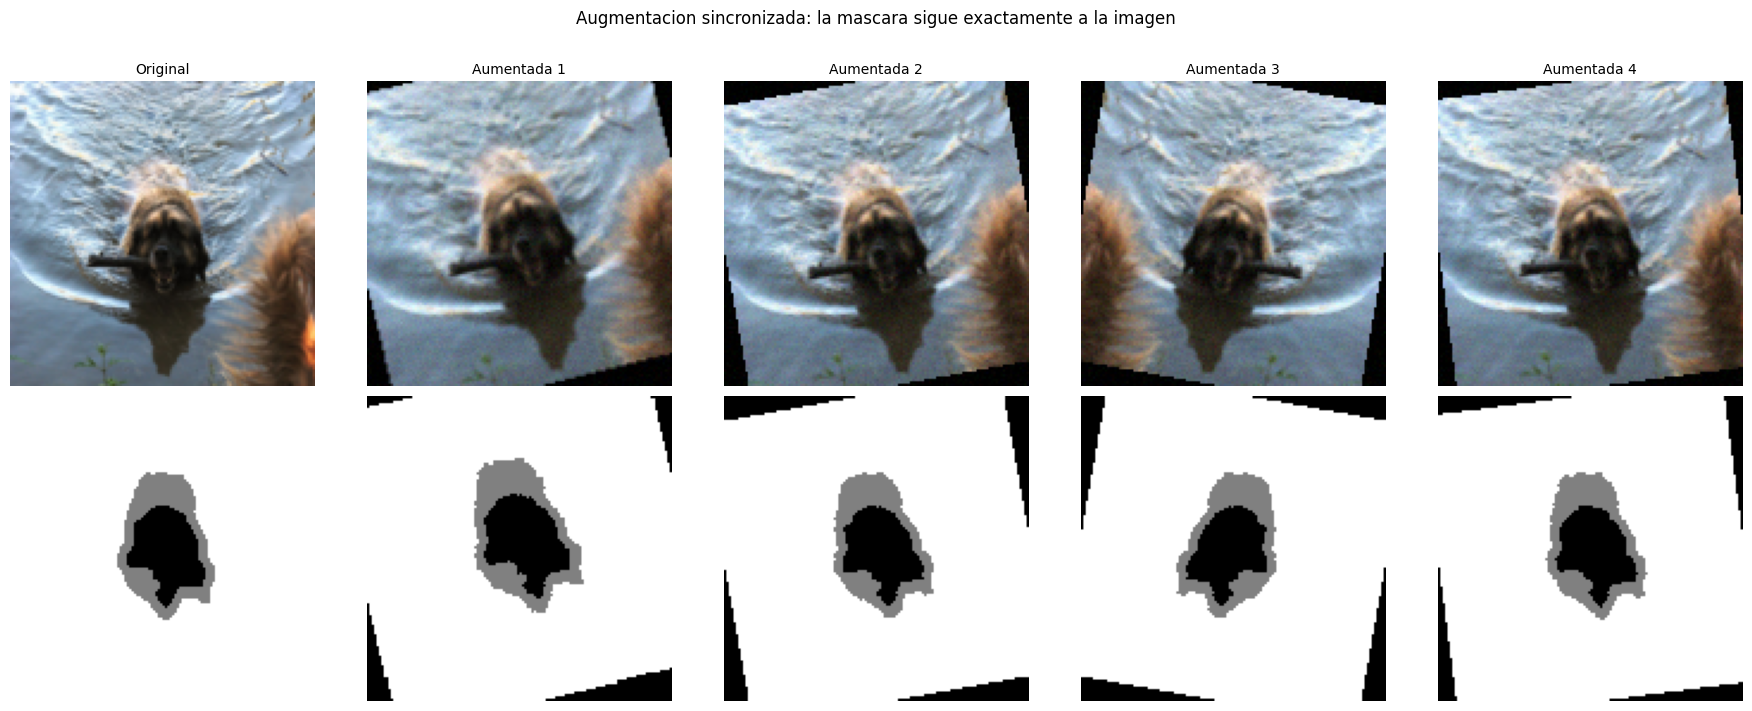

In [10]:
def mask_to_rgb(mask):
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for c, col in enumerate(CLASS_COLORS):
        rgb[mask == c] = col
    return rgb
class SyncAug:
    """Augmentacion sincronizada imagen+mascara para segmentacion."""

    def __init__(self, hflip=0.5, vflip=0.2, rot=15, crop=0.5,
                 scale=(0.75, 1.0), noise=0.02, h=256, w=256):
        self.hflip, self.vflip = hflip, vflip
        self.rot, self.crop    = rot, crop
        self.scale, self.noise = scale, noise
        self.h, self.w         = h, w

    def __call__(self, img_t, mask_t):
        img  = Image.fromarray((img_t.permute(1,2,0).numpy()*255).astype(np.uint8))
        mask = Image.fromarray(mask_t.numpy().astype(np.uint8), mode='L')

        if random.random() < self.hflip:
            img  = img.transpose(Image.FLIP_LEFT_RIGHT)
            mask = mask.transpose(Image.FLIP_LEFT_RIGHT)

        if random.random() < self.vflip:
            img  = img.transpose(Image.FLIP_TOP_BOTTOM)
            mask = mask.transpose(Image.FLIP_TOP_BOTTOM)

        if self.rot > 0:
            ang  = random.uniform(-self.rot, self.rot)
            img  = img.rotate(ang, resample=Image.BILINEAR, expand=False)
            mask = mask.rotate(ang, resample=Image.NEAREST,  expand=False)

        if random.random() < self.crop:
            s  = random.uniform(*self.scale)
            nh, nw = int(self.h*s), int(self.w*s)
            t  = random.randint(0, self.h-nh)
            l  = random.randint(0, self.w-nw)
            img  = img.crop((l,t,l+nw,t+nh)).resize((self.w,self.h), Image.BILINEAR)
            mask = mask.crop((l,t,l+nw,t+nh)).resize((self.w,self.h), Image.NEAREST)

        img_out = torch.from_numpy(np.array(img)).permute(2,0,1).float()/255.0
        if self.noise > 0:
            img_out = (img_out + torch.randn_like(img_out)*self.noise).clamp(0,1)

        return img_out, torch.from_numpy(np.array(mask)).long()


# Visualizar augmentacion sincronizada
aug = SyncAug(h=IMG_H, w=IMG_W)
img0, mask0 = train_dataset[0]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes[0,0].imshow((img0.permute(1,2,0).numpy()*255).astype(np.uint8))
axes[1,0].imshow(mask_to_rgb(mask0.numpy()))
axes[0,0].set_title('Original', fontsize=10)

for col in range(1,5):
    random.seed(col*17)
    ia, ma = aug(img0, mask0)
    axes[0,col].imshow((ia.permute(1,2,0).numpy()*255).astype(np.uint8))
    axes[1,col].imshow(mask_to_rgb(ma.numpy()))
    axes[0,col].set_title(f'Aumentada {col}', fontsize=10)

for ax in axes.flatten(): ax.axis('off')
axes[0,0].set_ylabel('Imagen', fontsize=11, rotation=0, labelpad=40, va='center')
axes[1,0].set_ylabel('Mascara', fontsize=11, rotation=0, labelpad=40, va='center')
plt.suptitle('Augmentacion sincronizada: la mascara sigue exactamente a la imagen', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---

## 8. Entrenamiento y comparativa de arquitecturas

In [11]:
def train(model, train_loader, val_loader, epochs=40, lr=1e-3,
          loss_fn='combined', n_classes=4, class_weights=None, device='cpu'):
    """
    Bucle de entrenamiento para segmentacion semantica.
    ReduceLROnPlateau monitorea el mIoU de validacion:
    si no mejora en 5 epocas consecutivas, reduce el lr a la mitad.
    """
    opt  = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=5)
    hist = {'train_loss':[], 'val_miou':[], 'val_dice':[]}
    best = 0.0

    for epoch in range(1, epochs+1):
        model.train(); total = 0.0
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            lg = model(imgs)
            if   loss_fn == 'ce':       loss = SegLoss.ce(lg, masks)
            elif loss_fn == 'wce':      loss = SegLoss.ce(lg, masks, class_weights)
            elif loss_fn == 'dice':     loss = SegLoss.dice(lg, masks, n_classes)
            elif loss_fn == 'focal':    loss = SegLoss.focal(lg, masks)
            elif loss_fn == 'combined': loss = SegLoss.combined(lg, masks, n_classes, class_weights)
            else: raise ValueError(f'Loss desconocida: {loss_fn}')
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()

        avg = total / len(train_loader)
        vm  = evaluate(model, val_loader, n_classes, device)
        sched.step(vm['mIoU'])
        hist['train_loss'].append(avg)
        hist['val_miou'].append(vm['mIoU'])
        hist['val_dice'].append(vm['mean_dice'])
        if vm['mIoU'] > best: best = vm['mIoU']

        if epoch % 5 == 0 or epoch == 1:
            lr_now = opt.param_groups[0]['lr']
            print(f'Epoca {epoch:3d}/{epochs}  '
                  f'Loss:{avg:.4f}  mIoU:{vm["mIoU"]:.4f}  '
                  f'Dice:{vm["mean_dice"]:.4f}  lr:{lr_now:.1e}')

    print(f'Mejor mIoU val: {best:.4f}')
    return hist


fcn_model = SimpleFCN(N_CLASSES, f=32).to(device)
print('Entrenando FCN...')
hist_fcn = train(fcn_model, train_loader, val_loader,
                 epochs=40, lr=1e-3, loss_fn='combined',
                 n_classes=N_CLASSES, class_weights=class_weights, device=device)

Entrenando FCN...
Epoca   1/40  Loss:1.0797  mIoU:0.4882  Dice:0.6340  lr:1.0e-03
Epoca   5/40  Loss:0.8124  mIoU:0.5579  Dice:0.6954  lr:1.0e-03
Epoca  10/40  Loss:0.7128  mIoU:0.6137  Dice:0.7398  lr:1.0e-03
Epoca  15/40  Loss:0.6276  mIoU:0.6122  Dice:0.7397  lr:1.0e-03
Epoca  20/40  Loss:0.5677  mIoU:0.6335  Dice:0.7557  lr:1.0e-03
Epoca  25/40  Loss:0.5091  mIoU:0.6459  Dice:0.7645  lr:1.0e-03
Epoca  30/40  Loss:0.4809  mIoU:0.6333  Dice:0.7556  lr:1.0e-03
Epoca  35/40  Loss:0.3881  mIoU:0.6385  Dice:0.7593  lr:5.0e-04
Epoca  40/40  Loss:0.3735  mIoU:0.6452  Dice:0.7644  lr:5.0e-04
Mejor mIoU val: 0.6523


In [14]:
unet_model = UNet(3, N_CLASSES, f=32).to(device)
print('Entrenando U-Net...')
hist_unet = train(unet_model, train_loader, val_loader,
                  epochs=10, lr=1e-3, loss_fn='combined',
                  n_classes=N_CLASSES, class_weights=class_weights, device=device)

Entrenando U-Net...
Epoca   1/10  Loss:1.0104  mIoU:0.4928  Dice:0.6461  lr:1.0e-03
Epoca   5/10  Loss:0.6753  mIoU:0.5564  Dice:0.7048  lr:1.0e-03
Epoca  10/10  Loss:0.5718  mIoU:0.6794  Dice:0.7951  lr:1.0e-03
Mejor mIoU val: 0.6794


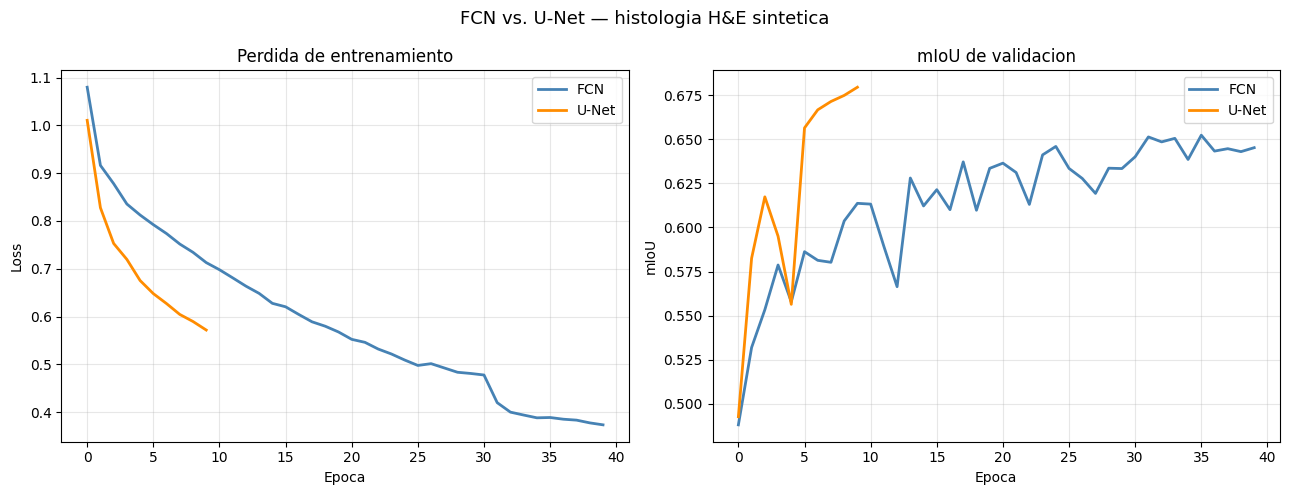

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for hist, name, color in [(hist_fcn,'FCN','steelblue'),(hist_unet,'U-Net','darkorange')]:
    axes[0].plot(hist['train_loss'], label=name, color=color, lw=2)
    axes[1].plot(hist['val_miou'],   label=name, color=color, lw=2)
axes[0].set(title='Perdida de entrenamiento', xlabel='Epoca', ylabel='Loss')
axes[1].set(title='mIoU de validacion',       xlabel='Epoca', ylabel='mIoU')
for ax in axes: ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('FCN vs. U-Net', fontsize=13)
plt.tight_layout()
plt.show()

---

## 9. Analisis de resultados

In [16]:
fcn_res  = evaluate(fcn_model,  test_loader, N_CLASSES, device)
unet_res = evaluate(unet_model, test_loader, N_CLASSES, device)

print('Resultados en test set')
print('=' * 60)
print(f'{"Metrica":<20} {"FCN":>10} {"U-Net":>10}')
print('-' * 60)
for key, label in [('pixel_acc','Pixel Accuracy'),('mIoU','mIoU'),('mean_dice','Mean Dice')]:
    print(f'{label:<20} {fcn_res[key]:>10.4f} {unet_res[key]:>10.4f}')
print('\nIoU y Dice por clase:')
print(f'{"Clase":<20} {"IoU FCN":>8} {"IoU UNet":>9} {"Dice FCN":>9} {"Dice UNet":>9}')
print('-' * 60)
fmt = lambda v: f'{v:.4f}' if not np.isnan(v) else '  N/A '
for c in range(N_CLASSES):
    print(f'{CLASS_NAMES[c]:<20} '
          f'{fmt(fcn_res["iou_per_class"][c]):>8} '
          f'{fmt(unet_res["iou_per_class"][c]):>9} '
          f'{fmt(fcn_res["dice_per_class"][c]):>9} '
          f'{fmt(unet_res["dice_per_class"][c]):>9}')

Resultados en test set
Metrica                     FCN      U-Net
------------------------------------------------------------
Pixel Accuracy           0.8433     0.8579
mIoU                     0.6541     0.6882
Mean Dice                0.7731     0.8035

IoU y Dice por clase:
Clase                 IoU FCN  IoU UNet  Dice FCN Dice UNet
------------------------------------------------------------
Fondo                  0.7236    0.7451    0.8396    0.8539
Mascota                0.8478    0.8539    0.9176    0.9212
Borde                  0.3908    0.4657    0.5619    0.6354


Predicciones de U-Net en test set:


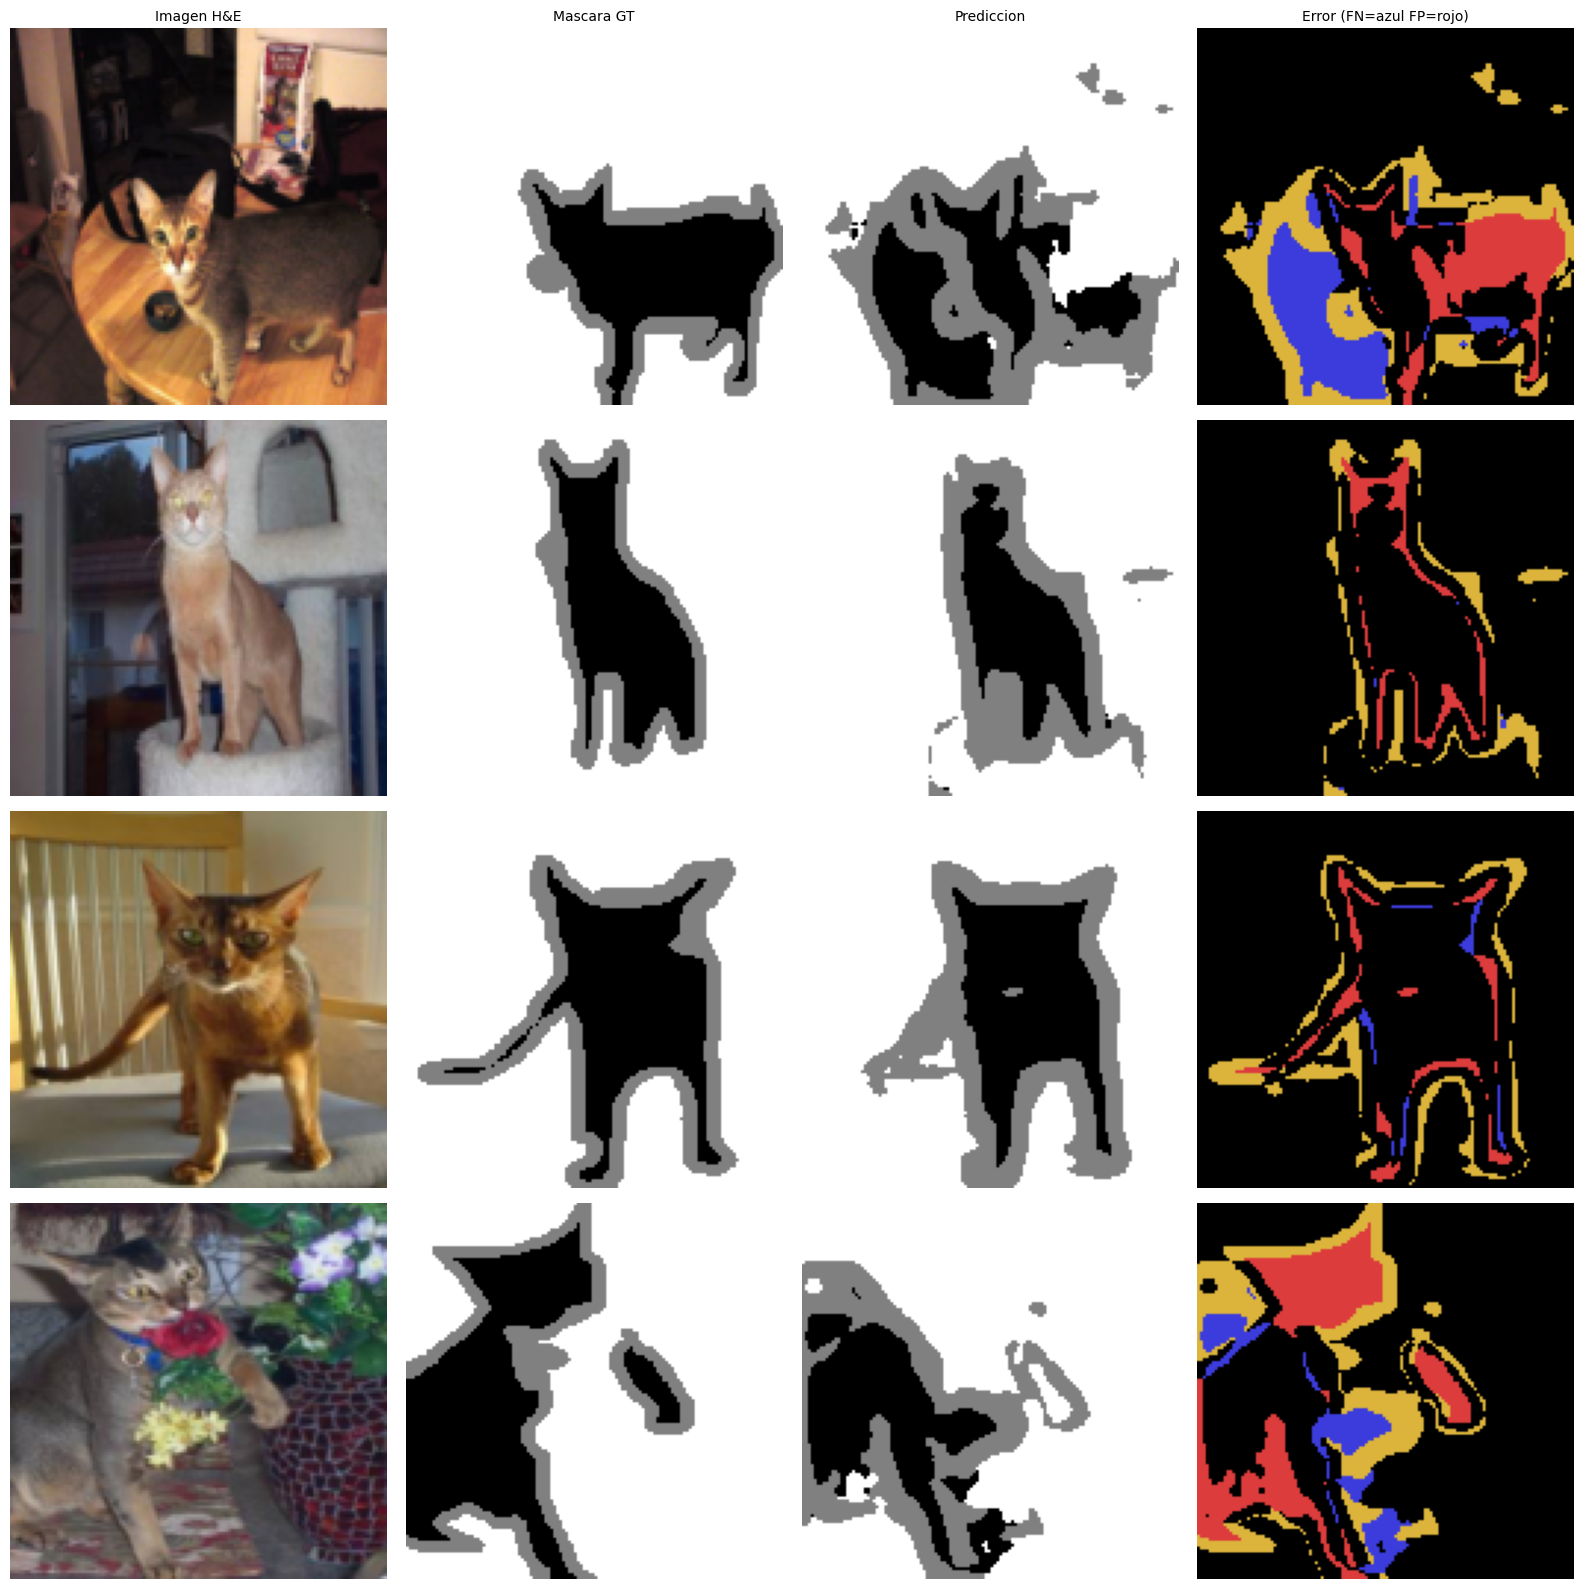

In [17]:
def viz_preds(model, dataset, indices, n_classes, device):
    model.eval()
    n = len(indices)
    fig, axes = plt.subplots(n, 4, figsize=(16, n*4))
    if n == 1: axes = axes[np.newaxis,:]

    for row, idx in enumerate(indices):
        img_t, mask_t = dataset[idx]
        img_np = (img_t.permute(1,2,0).numpy()*255).astype(np.uint8)
        with torch.no_grad():
            pred = model(img_t.unsqueeze(0).to(device)).argmax(1).squeeze(0).cpu()

        # Mapa de error: FN azul, FP rojo, clase incorrecta amarillo
        err = np.zeros((*mask_t.shape, 3), dtype=np.uint8)
        err[(mask_t.numpy()!=0)&(pred.numpy()==0)]                                = [60,60,220]
        err[(mask_t.numpy()==0)&(pred.numpy()!=0)]                                = [220,60,60]
        err[(mask_t.numpy()!=0)&(pred.numpy()!=0)&(mask_t.numpy()!=pred.numpy())] = [220,180,60]

        miou_i = SegMetrics.miou(pred, mask_t, n_classes)
        axes[row,0].imshow(img_np)
        axes[row,1].imshow(mask_to_rgb(mask_t.numpy()))
        axes[row,2].imshow(mask_to_rgb(pred.numpy()))
        axes[row,3].imshow(err)
        for ax in axes[row]: ax.axis('off')
        axes[row,0].set_ylabel(f'mIoU={miou_i:.3f}', fontsize=9, rotation=0, labelpad=55, va='center')

    for ax, t in zip(axes[0], ['Imagen H&E','Mascara GT','Prediccion','Error (FN=azul FP=rojo)']):
        ax.set_title(t, fontsize=10)
    plt.tight_layout()
    plt.show()


print('Predicciones de U-Net en test set:')
viz_preds(unet_model, test_dataset, [0,1,2,3], N_CLASSES, device)

In [ ]:
# Impacto de la funcion de perdida en U-Net
res_loss = {}
for lname in ['ce', 'wce', 'dice', 'focal', 'combined']:
    print(f'U-Net con perdida: {lname}')
    m = UNet(3, N_CLASSES, f=32).to(device)
    h = train(m, train_loader, val_loader, epochs=30, lr=1e-3,
              loss_fn=lname, n_classes=N_CLASSES, class_weights=class_weights, device=device)
    tm = evaluate(m, test_loader, N_CLASSES, device)
    res_loss[lname] = {'hist': h, 'test': tm}
    print(f'  Test -> mIoU:{tm["mIoU"]:.4f}  Dice:{tm["mean_dice"]:.4f}\n')

U-Net con perdida: ce


In [ ]:
# Tabla resumen por funcion de perdida
print('U-Net en test set — impacto de la funcion de perdida')
print('='*62)
print(f'{"Perdida":<12} {"PA":>7} {"mIoU":>7} {"Dice":>7}  IoU por clase')
print('-'*62)
fmt = lambda v: f'{v:.3f}' if not np.isnan(v) else ' N/A'
for name, r in res_loss.items():
    t = r['test']
    ious = '  '.join([fmt(v) for v in t['iou_per_class']])
    print(f'{name:<12} {t["pixel_acc"]:>7.4f} {t["mIoU"]:>7.4f} {t["mean_dice"]:>7.4f}  [{ious}]')

# Curvas de convergencia
colors = ['steelblue','darkorange','seagreen','mediumpurple','crimson']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for (name, r), color in zip(res_loss.items(), colors):
    axes[0].plot(r['hist']['val_miou'],   label=name, color=color, lw=2)
    axes[1].plot(r['hist']['train_loss'], label=name, color=color, lw=2)
axes[0].set(title='mIoU de validacion', xlabel='Epoca', ylabel='mIoU')
axes[1].set(title='Perdida de entrenamiento', xlabel='Epoca', ylabel='Loss')
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.suptitle('Impacto de la funcion de perdida (U-Net, histologia H&E)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Barras IoU y Dice por clase: FCN vs U-Net
x, w = np.arange(N_CLASSES), 0.35
fi   = [v if not np.isnan(v) else 0 for v in fcn_res['iou_per_class']]
ui   = [v if not np.isnan(v) else 0 for v in unet_res['iou_per_class']]
fd   = [v if not np.isnan(v) else 0 for v in fcn_res['dice_per_class']]
ud   = [v if not np.isnan(v) else 0 for v in unet_res['dice_per_class']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, fv, uv, lbl in [(axes[0],fi,ui,'IoU'),(axes[1],fd,ud,'Dice')]:
    b1 = ax.bar(x-w/2, fv, w, label='FCN',   color='steelblue',  alpha=0.85)
    b2 = ax.bar(x+w/2, uv, w, label='U-Net', color='darkorange', alpha=0.85)
    ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=8)
    ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(lbl); ax.set_ylim(0,1.12); ax.set_title(f'{lbl} por clase')
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('FCN vs. U-Net — metricas por clase en test set (histologia H&E)', fontsize=12)
plt.tight_layout()
plt.show()

---

## Conclusiones

**Dataset**: el dataset sintetico de histologia H&E usa ruido gaussiano filtrado y elipses rotadas para reproducir las propiedades estadisticas de las imagenes medicas reales: texturas organicas, morfologia celular irregular, distribucion agrupada de nucleos y desbalance de clases. Se sustituye directamente por Oxford Pet, ISIC, DRIVE o MoNuSeg sin cambiar el codigo de arquitecturas ni entrenamiento.

**FCN vs. U-Net**: la FCN muestra peor precision en bordes porque el upsampling bilineal desde H/16 no puede recuperar detalles finos. Las skip connections de U-Net proveen informacion espacial en cada nivel de resolucion, lo que se traduce en mIoU y Dice superiores especialmente en estructuras pequeñas como nucleos y lumen.

**Funciones de perdida**: la Cross-Entropy pura falla con desbalance porque el gradiente lo domina el fondo. Dice Loss trata todas las clases por igual. La perdida combinada CE + Dice es la mas robusta: CE aporta convergencia estable y Dice optimiza la superposicion region a region.

**Metricas**: la Pixel Accuracy es engañosa con desbalance severo. El **mIoU** y el **Dice por clase** son las referencias porque promedian el rendimiento sin sesgo hacia la clase mayoritaria.

---

## Referencias

- Long, J., Shelhamer, E., & Darrell, T. (2015). Fully convolutional networks for semantic segmentation. *CVPR 2015*.
- Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. *MICCAI 2015*.
- Milletari, F., Navab, N., & Ahmadi, S.A. (2016). V-Net: Fully convolutional neural networks for volumetric medical image segmentation. *3DV 2016*.
- Lin, T.Y., et al. (2017). Focal loss for dense object detection. *ICCV 2017*.
- Isensee, F., et al. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. *Nature Methods*.